# **TRAFFIC SIGN DETECTION**

---
## 1. Install & Import Libraries

In [2]:
!pip install opencv-python seaborn scikit-learn tqdm

import os, zipfile, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as res_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [1]:
from warnings import filterwarnings
filterwarnings('ignore')

In [ ]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

---
## 2. MOUNT GOOGLE DRIVE

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 3. Unzip Dataset

In [4]:
zip_path = "/content/drive/MyDrive/AI Projects/Traffic Sign /PRAICP-1002-TrafSignDetc.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


---
## 4. Dataset Paths

In [5]:
base_path = "/content/data"
train_dir = os.path.join(base_path, "Train")
test_dir = os.path.join(base_path, "Test")
meta_dir = os.path.join(base_path, "Meta")

In [ ]:
import shutil

shutil.copytree(
    '/kaggle/input/datasets/thomasmathewz/praicp-1002-trafsigndetc',
    '/kaggle/working/data',
    dirs_exist_ok=True
)

base_path = "/kaggle/working/data/PRAICP-1002-TrafSignDetc"
train_dir = os.path.join(base_path, "Train")
test_dir = os.path.join(base_path, "Test")
meta_dir = os.path.join(base_path, "Meta")

---
## 5. Filter Only Valid Images

In [ ]:

valid_ext = [".jpg", ".png", ".jpeg"]

def filter_images(directory):
    for root, dirs, files in os.walk(directory):
        for file in files:
            if not any(file.lower().endswith(ext) for ext in valid_ext):
                os.remove(os.path.join(root, file))

filter_images(train_dir)
filter_images(test_dir)
filter_images(meta_dir)

print("Filtered non-image files!")

Filtered non-image files!


---
## 6. Exploratory Data Analysis

---
### 6.1 Class Distribution

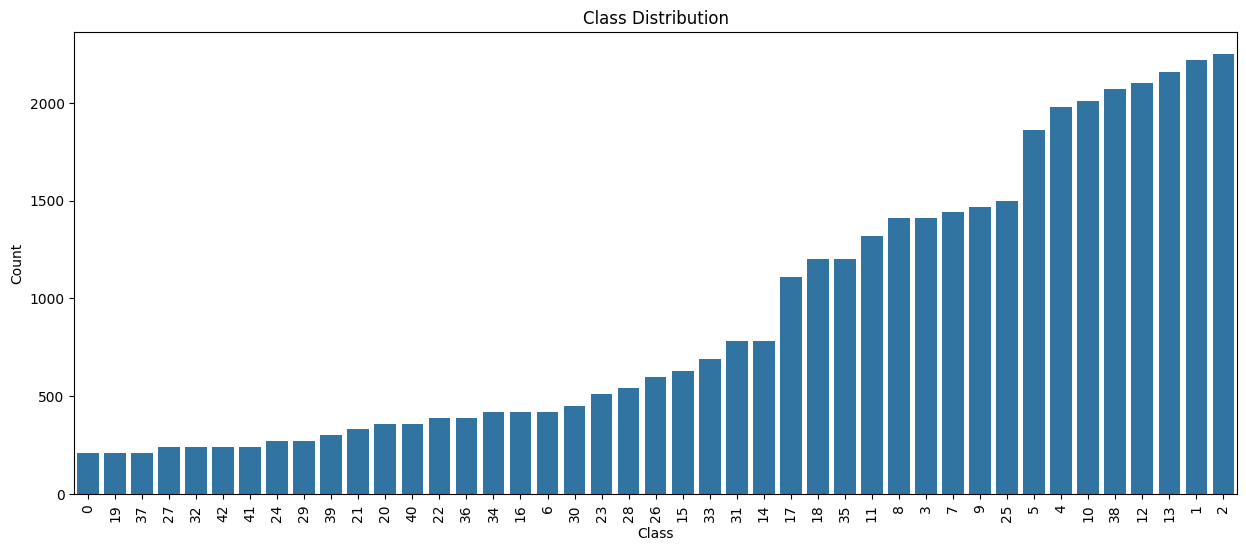

In [ ]:
class_counts = {}

for cls in sorted(os.listdir(train_dir)):
    class_counts[cls] = len(os.listdir(os.path.join(train_dir, cls)))

df = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"])
df = df.sort_values("Count")

plt.figure(figsize=(15,6))
sns.barplot(x="Class", y="Count", data=df)
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

---
### 6.2 Check Imbalance

In [ ]:
print("Min samples:", df["Count"].min())
print("Max samples:", df["Count"].max())
print("Imbalance ratio:", df["Count"].max()/df["Count"].min())

Min samples: 210
Max samples: 2250
Imbalance ratio: 10.714285714285714


---
### 6.3 Sample Images Visualization

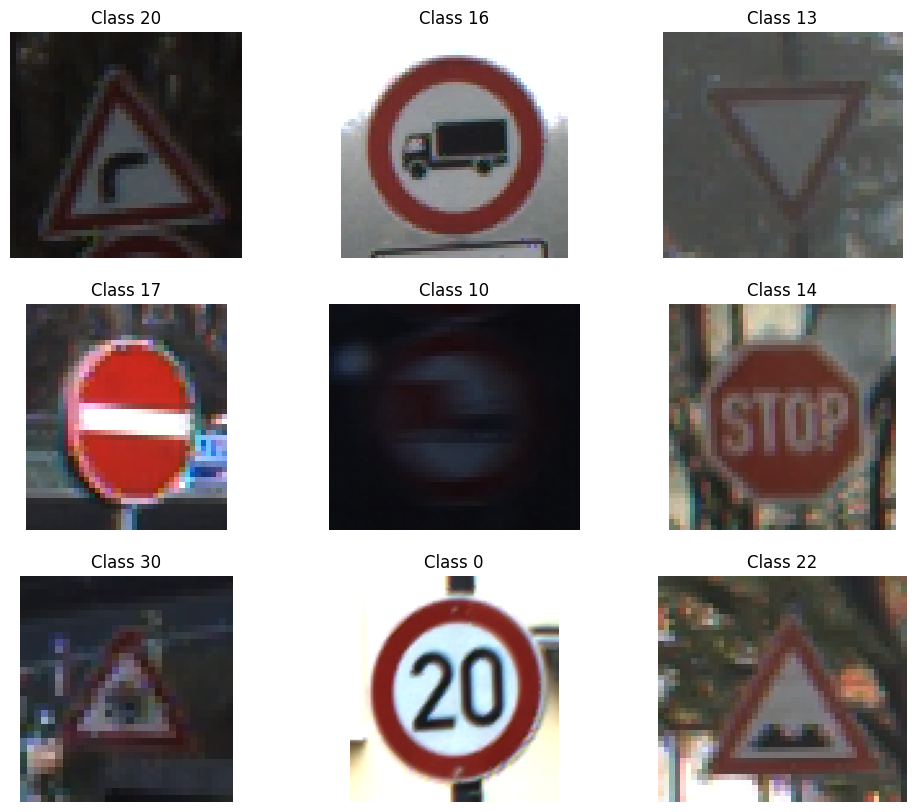

In [ ]:
plt.figure(figsize=(12,10))

for i, cls in enumerate(os.listdir(train_dir)[:9]):
    img_path = os.path.join(train_dir, cls, os.listdir(os.path.join(train_dir, cls))[0])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"Class {cls}")
    plt.axis("off")

plt.show()

---
### 6.4 Image Size Distribution

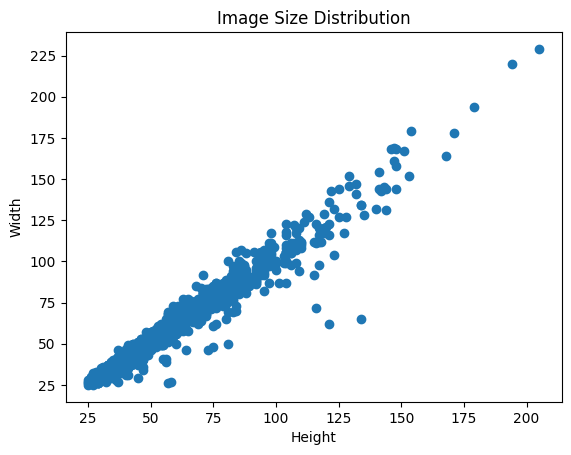

In [ ]:
sizes = []

for cls in os.listdir(train_dir):
    for file in os.listdir(os.path.join(train_dir, cls))[:50]:
        img = cv2.imread(os.path.join(train_dir, cls, file))
        sizes.append(img.shape[:2])

sizes = np.array(sizes)

plt.scatter(sizes[:,0], sizes[:,1])
plt.xlabel("Height")
plt.ylabel("Width")
plt.title("Image Size Distribution")
plt.show()

---
### 6.5 Pixel Intensity Distribution

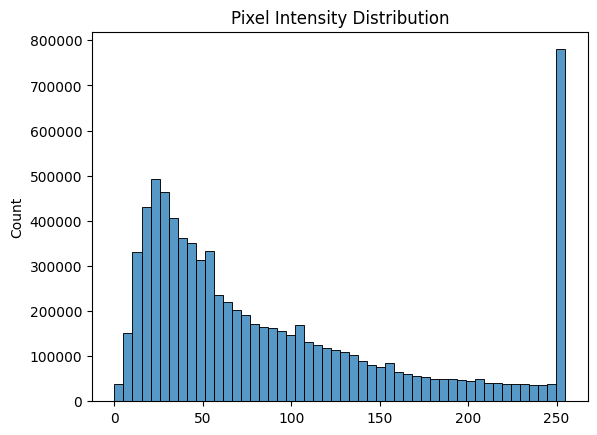

In [ ]:
pixels = []

for cls in os.listdir(train_dir):
    for file in os.listdir(os.path.join(train_dir, cls))[:20]:
        img = cv2.imread(os.path.join(train_dir, cls, file))
        pixels.extend(img.flatten())

sns.histplot(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

---
### 6.6 Mean & Std

In [ ]:
pixels = np.array(pixels)

print("Mean:", np.mean(pixels))
print("Std:", np.std(pixels))

Mean: 92.92881435483639
Std: 76.53405659905641


---
## 7. Data Augmentation

---
### 7.1 CNN Data Generators

In [ ]:
# IMG_SIZE = (224,224)
# BATCH_SIZE = 32
IMG_SIZE = (128,128)
BATCH_SIZE = 16

train_datagen_cnn = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.3,
    width_shift_range=0.15,
    height_shift_range=0.15,
    validation_split=0.2
)

train_gen = train_datagen_cnn.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training'
)

val_gen = train_datagen_cnn.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation'
)

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


---
### 7.2 Transfer Learning Generators

In [ ]:
train_gen_vgg = ImageDataGenerator(preprocessing_function=vgg_pre, validation_split=0.2)\
    .flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, subset='training')

val_gen_vgg = ImageDataGenerator(preprocessing_function=vgg_pre, validation_split=0.2)\
    .flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, subset='validation')

train_gen_res = ImageDataGenerator(preprocessing_function=res_pre, validation_split=0.2)\
    .flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, subset='training')

val_gen_res = ImageDataGenerator(preprocessing_function=res_pre, validation_split=0.2)\
    .flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, subset='validation')

train_gen_eff = ImageDataGenerator(preprocessing_function=eff_pre, validation_split=0.2)\
    .flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, subset='training')

val_gen_eff = ImageDataGenerator(preprocessing_function=eff_pre, validation_split=0.2)\
    .flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, subset='validation')

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.
Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.
Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


---
### 7.3 Class Weights

In [ ]:
classes = train_gen.classes
class_weights = compute_class_weight('balanced', classes=np.unique(classes), y=classes)
class_weights = dict(enumerate(class_weights))

---
## 8. MODELS
- Custom CNN Model 1
- Custom CNN Model 2 (Deeper)
- VGG16
- ResNet50
- MobileNetV2


---
### 8.1 Model 1: Basic CNN

In [ ]:
cnn1 = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(128,128, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(43, activation='softmax')
])

cnn1.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

I0000 00:00:1774261068.966144      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774261068.972080      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


---
### 8.2 Model 2: Deep CNN

In [ ]:
cnn2 = models.Sequential([
    layers.Conv2D(64, 3, activation='relu', input_shape=(128,128, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(43, activation='softmax')
])

cnn2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

---
### 8.3 Model 3: CNN + GlobalAvgPool

In [ ]:
cnn3 = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(128,128, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(43, activation='softmax')
])

cnn3.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

---
### 8.4 Model 4: VGG16 (Fine-tuned)

In [ ]:
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))

for layer in base_vgg.layers[:-30]:
    layer.trainable = False

x = layers.Flatten()(base_vgg.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(43, activation='softmax')(x)

vgg_model = models.Model(inputs=base_vgg.input, outputs=out)

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


---
### 8.5 Model 5: ResNet50 (Fine-tuned)

In [ ]:
base_res = ResNet50(weights='imagenet', include_top=False, input_shape=(128,128,3))

for layer in base_res.layers[:-30]:
    layer.trainable = False

x = layers.GlobalAveragePooling2D()(base_res.output)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(43, activation='softmax')(x)

resnet_model = models.Model(inputs=base_res.input, outputs=out)

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


---
### 8.6 Model 6: EfficientNetB0 (Best performer usually)

In [ ]:
base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(128,128,3))

for layer in base_eff.layers[:-30]:
    layer.trainable = False

x = layers.GlobalAveragePooling2D()(base_eff.output)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(43, activation='softmax')(x)

eff_model = models.Model(inputs=base_eff.input, outputs=out)

eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


---
### 8.7 Model Training

In [ ]:
histories = {}


histories["cnn1"] = cnn1.fit(train_gen, validation_data=val_gen, epochs=20,
                             callbacks=[
                             EarlyStopping(patience=5, restore_best_weights=True),
                             ReduceLROnPlateau(patience=3)]
                                 )
histories["cnn2"] = cnn2.fit(train_gen, validation_data=val_gen, epochs=20,
                             callbacks=[
                                EarlyStopping(patience=5, restore_best_weights=True),
                                ReduceLROnPlateau(patience=3)]
                                 )
histories["cnn3"] = cnn3.fit(train_gen, validation_data=val_gen, epochs=20,
                             callbacks=[
                                EarlyStopping(patience=5, restore_best_weights=True),
                                ReduceLROnPlateau(patience=3)]
                                 )

histories["vgg_model"] = vgg_model.fit(train_gen_vgg, validation_data=val_gen_vgg, epochs=10)
histories["resnet_model"] = resnet_model.fit(train_gen_res, validation_data=val_gen_res, epochs=10)
histories["eff_model"] = eff_model.fit(train_gen_eff, validation_data=val_gen_eff, epochs=10)


Epoch 1/20


I0000 00:00:1774261077.756732     197 service.cc:152] XLA service 0x7c2330005400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774261077.756784     197 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774261077.756790     197 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774261078.381191     197 cuda_dnn.cc:529] Loaded cuDNN version 91002


   4/1961 ━━━━━━━━━━━━━━━━━━━━ 1:42 52ms/step - accuracy: 0.0378 - loss: 4.9814    

I0000 00:00:1774261084.130808     197 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1961/1961 ━━━━━━━━━━━━━━━━━━━━ 186s 91ms/step - accuracy: 0.1775 - loss: 3.7456 - val_accuracy: 0.2787 - val_loss: 2.9443 - learning_rate: 1.0000e-04
Epoch 2/20
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 171s 87ms/step - accuracy: 0.3199 - loss: 2.5813 - val_accuracy: 0.3454 - val_loss: 2.5755 - learning_rate: 1.0000e-04
Epoch 3/20
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 171s 87ms/step - accuracy: 0.3781 - loss: 2.1704 - val_accuracy: 0.3713 - val_loss: 2.2746 - learning_rate: 1.0000e-04
Epoch 4/20
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 169s 86ms/step - accuracy: 0.4291 - loss: 1.9058 - val_accuracy: 0.4020 - val_loss: 2.1969 - learning_rate: 1.0000e-04
Epoch 5/20
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 171s 87ms/step - accuracy: 0.4698 - loss: 1.7255 - val_accuracy: 0.4164 - val_loss: 2.1265 - learning_rate: 1.0000e-04
Epoch 6/20
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 171s 87ms/step - accuracy: 0.5064 - loss: 1.5577 - val_accuracy: 0.4260 - val_loss: 1.9972 - learning_rate: 1.0000e-04
Epoch 7/20
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 170

2026-03-23 13:09:41.296780: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-23 13:09:41.434334: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 570/1961 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.0376 - loss: 4.6139

2026-03-23 13:10:46.751756: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-23 13:10:46.886783: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1961/1961 ━━━━━━━━━━━━━━━━━━━━ 205s 67ms/step - accuracy: 0.0982 - loss: 4.0887 - val_accuracy: 0.4371 - val_loss: 2.1418
Epoch 2/10
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.3816 - loss: 2.3756 - val_accuracy: 0.5563 - val_loss: 1.5989
Epoch 3/10
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.5064 - loss: 1.7831 - val_accuracy: 0.6120 - val_loss: 1.3283
Epoch 4/10
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.5915 - loss: 1.4268 - val_accuracy: 0.6590 - val_loss: 1.1440
Epoch 5/10
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.6380 - loss: 1.2116 - val_accuracy: 0.6887 - val_loss: 1.0295
Epoch 6/10
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.6911 - loss: 1.0305 - val_accuracy: 0.7133 - val_loss: 0.9439
Epoch 7/10
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.7195 - loss: 0.9168 - val_accuracy: 0.7294 - val_loss: 0.8877
Epoch 8/10
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.7532 - loss: 0.8

---
## 9. Final Visualizations

---
### 9.1 Model Metrics Table

In [ ]:
results = []

for name, history in histories.items():
    best_val_acc = max(history.history['val_accuracy'])
    best_val_loss = min(history.history['val_loss'])

    results.append({
        "Model": name,
        "Best Val Accuracy": best_val_acc,
        "Best Val Loss": best_val_loss
    })

results_df = pd.DataFrame(results)

# Sort by accuracy (best first)
results_df = results_df.sort_values(by="Best Val Accuracy", ascending=False)

print(results_df)

          Model  Best Val Accuracy  Best Val Loss
3     vgg_model           0.989925       0.045853
1          cnn2           0.912639       0.436379
4  resnet_model           0.832929       0.691082
5     eff_model           0.763040       0.775365
0          cnn1           0.569698       1.777039
2          cnn3           0.152787       3.105696


---
### 9.1 Accuracy Comparison

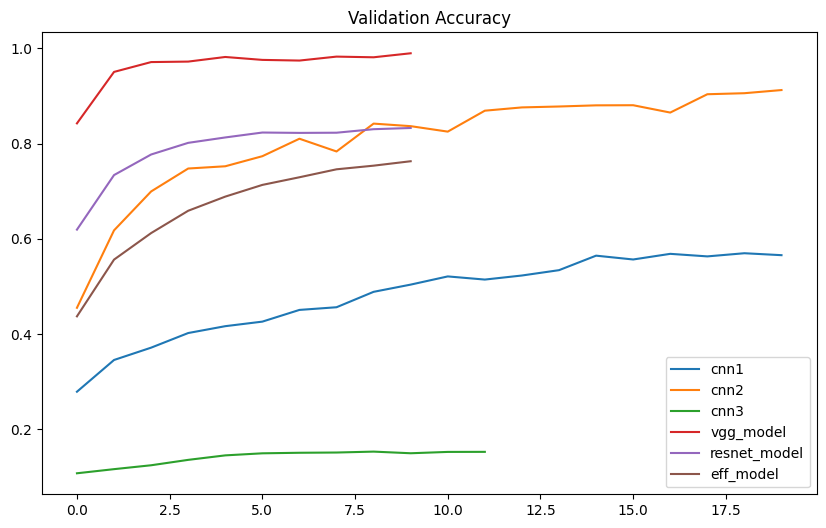

In [ ]:
plt.figure(figsize=(10,6))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.legend()
plt.title("Validation Accuracy")
plt.show()

---
### 9.2 Loss Comparison

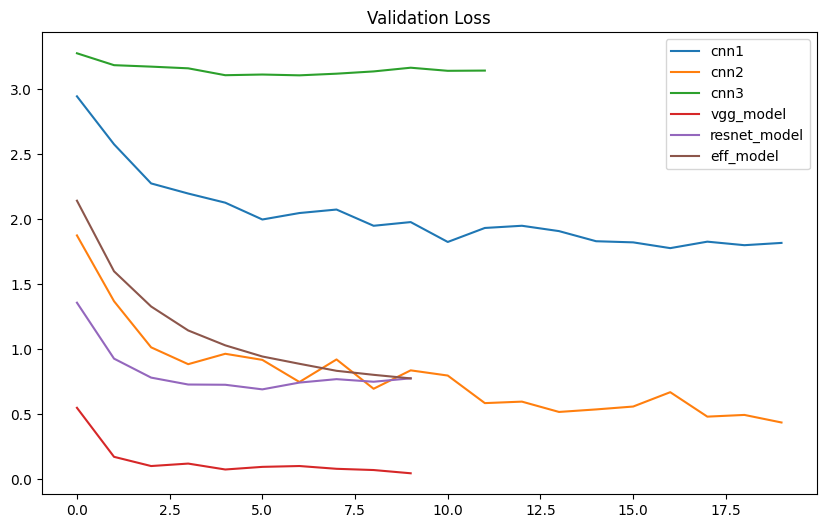

In [ ]:
plt.figure(figsize=(10,6))
for name, history in histories.items():
    plt.plot(history.history['val_loss'], label=name)

plt.legend()
plt.title("Validation Loss")
plt.show()

---
## **10. Conclusion**

In this project, multiple deep learning models were developed and evaluated for the task of traffic sign classification using a dataset consisting of 43 classes. The models included three custom convolutional neural networks (cnn1, cnn2, cnn3) and three transfer learning models (vgg_model, resnet_model, eff_model).

From the experimental results, it is evident that the VGG16-based model (vgg_model) achieved the highest validation accuracy of approximately 98.99% with the lowest validation loss, making it the most effective model among all those implemented. This superior performance can be attributed to the use of pretrained weights, which enable the model to leverage rich and generalized feature representations learned from large-scale datasets.

The custom CNN model (cnn2) also performed well, achieving over 91% validation accuracy. This indicates that a carefully designed convolutional architecture, even without pretrained weights, can learn meaningful features for traffic sign recognition. However, it still falls short compared to transfer learning approaches in terms of generalization.

The resnet_model and eff_model showed moderate performance, with accuracies of approximately 83% and 76% respectively. These results suggest that although these architectures are powerful, their performance is sensitive to factors such as input size, preprocessing, and fine-tuning strategy. With further optimization, these models could potentially achieve higher accuracy.

On the other hand, cnn1 and cnn3 performed poorly, indicating that shallow or less optimized architectures are insufficient for capturing the complexity of multi-class image classification tasks involving fine-grained visual differences.

Overall, the results demonstrate that transfer learning significantly enhances model performance in image classification tasks, especially when the dataset is limited in size or diversity. Among all models, vgg_model is selected as the final model due to its high accuracy, low loss, and stable learning behavior.

Future work can focus on improving model interpretability using techniques such as Grad-CAM, optimizing hyperparameters, and deploying the model in a real-time application using web frameworks such as Django or Flask.
